### Regular Neural Network - Overfitting to Noise
![ORB04_NN](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB04_phys_lambda0.png)

![ORB04_PINN](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB04_phys_lambda005.png)










### Look out for making the lambda physics too large, thus dominating the loss function
![lambda_phys_too_large](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB04_phys_lambda05.png)

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import copy

from torch.utils.data import TensorDataset, DataLoader

In [14]:
# directly copied from the first class
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
    !nvidia-smi
else:
    device = torch.device("cpu")

print("Selected device:", device)

PyTorch version: 2.7.0
CUDA available: False
Selected device: cpu


In [15]:
 # L-BFGS
# data loading and presenting
orbits = ['ORB04', "ORB11", "ORB12", "ORB14", "ORB19", "ORB26"]
# orbits = ['ORB04']


orbits_preproc_data = []


for i, orbit in enumerate(orbits):
    str = f"{orbits[i]}_EUR_EPHIO.csv"
    current_orbit_data = []
    df = pd.read_csv(str)

    # Inputs: X, Y, Z coordinates
    X_raw = df[['X', 'Y', 'Z']].values
    # Outputs: Magnetic Field Bx, By, Bz
    y_raw = df[['BX', 'BY', 'BZ']].values

    # Scale data to [-1, 1] for Tanh stability and easier gradient flow
    input_scaler = MinMaxScaler(feature_range=(-1, 1))
    output_scaler = MinMaxScaler(feature_range=(-1, 1))

    X_scaled = input_scaler.fit_transform(X_raw)
    y_scaled = output_scaler.fit_transform(y_raw)

    # to tensor
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

    # data split
    X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)


    current_orbit_data.append((X_raw, y_raw, X_train, y_train, X_val, y_val, input_scaler, output_scaler))
    orbits_preproc_data.append(current_orbit_data)

# print(orbits_preproc_data)  # Example: Print shape of raw inputs for first orbit

In [ ]:

# define the model
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        # Standard MLP architecture
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.SiLU(),
            nn.Linear(64, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 3)  # Output: Bx, By, Bz
        )

    def forward(self, x):
        return self.net(x)


In [17]:
def physics_loss_function(model, x_collocation):
  # gradient tracking
  x_collocation.requires_grad = True

  # predicts B-field
  b_pred = model(x_collocation)

  # separates components
  bx = b_pred[:, 0].unsqueeze(1)
  by = b_pred[:, 1].unsqueeze(1)
  bz = b_pred[:, 2].unsqueeze(1)

  # calculates gradients (d(Bi)/dxj)
  grads_bx = torch.autograd.grad(bx, x_collocation, grad_outputs=torch.ones_like(bx), create_graph=True)[0]
  dbx_dx, dbx_dy, dbx_dz = grads_bx[:, 0], grads_bx[:, 1], grads_bx[:, 2]

  grads_by = torch.autograd.grad(by, x_collocation, grad_outputs=torch.ones_like(by), create_graph=True)[0]
  dby_dx, dby_dy, dby_dz = grads_by[:, 0], grads_by[:, 1], grads_by[:, 2]

  grads_bz = torch.autograd.grad(bz, x_collocation, grad_outputs=torch.ones_like(bz), create_graph=True)[0]
  dbz_dx, dbz_dy, dbz_dz = grads_bz[:, 0], grads_bz[:, 1], grads_bz[:, 2]


  # first term - Gauss's law for magnetism div(B) = 0 -> divergence free -> no monopoles
  divergence = dbx_dx + dby_dy + dbz_dz
  loss_div = torch.mean(divergence**2)

  # second term - Ampere's law curl(B) = 0 -> irrotational -> current free
  curl_x = dbz_dy - dby_dz
  curl_y = dbx_dz - dbz_dx
  curl_z = dby_dx - dbx_dy
  loss_curl = torch.mean(curl_x**2 + curl_y**2 + curl_z**2)

  return loss_div + loss_curl
  ###################################

# function that generates random collocation points
def get_collocation_points(n_points=2000, bounds=(-1, 1), device=device):
  points = (bounds[1] - bounds[0] * torch.rand(n_points, 3, device=device) + bounds[0])
  return points.to(device)

In [18]:
epochs = 500
batch_size = 512
lambda_physics = 0.2

no_collocation_points = 300

# current_orbit_data.append((X_raw, y_raw, X_train, y_train, X_val, y_val, input_scaler, output_scaler))
orbits_models_data = []

for i, orbit_data in enumerate(orbits_preproc_data):
  model = PINN().to(device)
  optimizer = optim.Adam(model.parameters(), lr=1e-3)
  criterion_data = nn.MSELoss()

  print(f"Training on orbit: {orbits[i]}")

  X_train, y_train = orbit_data[0][2], orbit_data[0][3]

  train_dataset = TensorDataset(X_train, y_train)

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


  loss_history = {'data': [], 'physics': []}

  for epoch in range(epochs):
    model.train()

    epoch_data_loss = 0.0
    epoch_physics_loss = 0.0

    for batch_X, batch_y in train_loader:

      optimizer.zero_grad()

      # data loss
      pred_data = model(batch_X)
      loss_data = criterion_data(pred_data, batch_y)

      # physics loss
      ###################################
      x_phys = get_collocation_points(n_points=no_collocation_points, device=device)
      loss_physics = physics_loss_function(model, x_phys)


      loss_total = loss_data + lambda_physics * loss_physics

      ###################################
      loss_total.backward()
      optimizer.step()

      epoch_data_loss += loss_data.item()
      epoch_physics_loss += loss_physics.item()

    avg_data_loss = epoch_data_loss / len(train_loader)
    avg_physics_loss = epoch_physics_loss / len(train_loader)

    loss_history['data'].append(avg_data_loss)
    loss_history['physics'].append(avg_physics_loss)

    if (epoch + 1) % (epochs/10) == 0:
      print(f"Orbit: {orbits[i]} | Epoch {epoch + 1}/{epochs} | Data Loss: {avg_data_loss:.5f} | Physics Loss: {avg_physics_loss:.5f}")

  # orbits_models_data.append((model.state_dict(), loss_history))
  orbits_models_data.append((copy.deepcopy(model.state_dict()), loss_history))

Training on orbit: ORB04


Orbit: ORB04 | Epoch 50/500 | Data Loss: 0.00736 | Physics Loss: 0.00134
Orbit: ORB04 | Epoch 100/500 | Data Loss: 0.00664 | Physics Loss: 0.00070
Orbit: ORB04 | Epoch 150/500 | Data Loss: 0.00579 | Physics Loss: 0.00066
Orbit: ORB04 | Epoch 200/500 | Data Loss: 0.00498 | Physics Loss: 0.00079
Orbit: ORB04 | Epoch 250/500 | Data Loss: 0.00451 | Physics Loss: 0.00235
Orbit: ORB04 | Epoch 300/500 | Data Loss: 0.00425 | Physics Loss: 0.00052
Orbit: ORB04 | Epoch 350/500 | Data Loss: 0.00451 | Physics Loss: 0.00023
Orbit: ORB04 | Epoch 400/500 | Data Loss: 0.00401 | Physics Loss: 0.00011
Orbit: ORB04 | Epoch 450/500 | Data Loss: 0.00378 | Physics Loss: 0.00036
Orbit: ORB04 | Epoch 500/500 | Data Loss: 0.00408 | Physics Loss: 0.00041
Training on orbit: ORB11
Orbit: ORB11 | Epoch 50/500 | Data Loss: 0.02152 | Physics Loss: 0.00220
Orbit: ORB11 | Epoch 100/500 | Data Loss: 0.02114 | Physics Loss: 0.00114
Orbit: ORB11 | Epoch 150/500 | Data Loss: 0.02025 | Physics Loss: 0.00149
Orbit: ORB11 | 

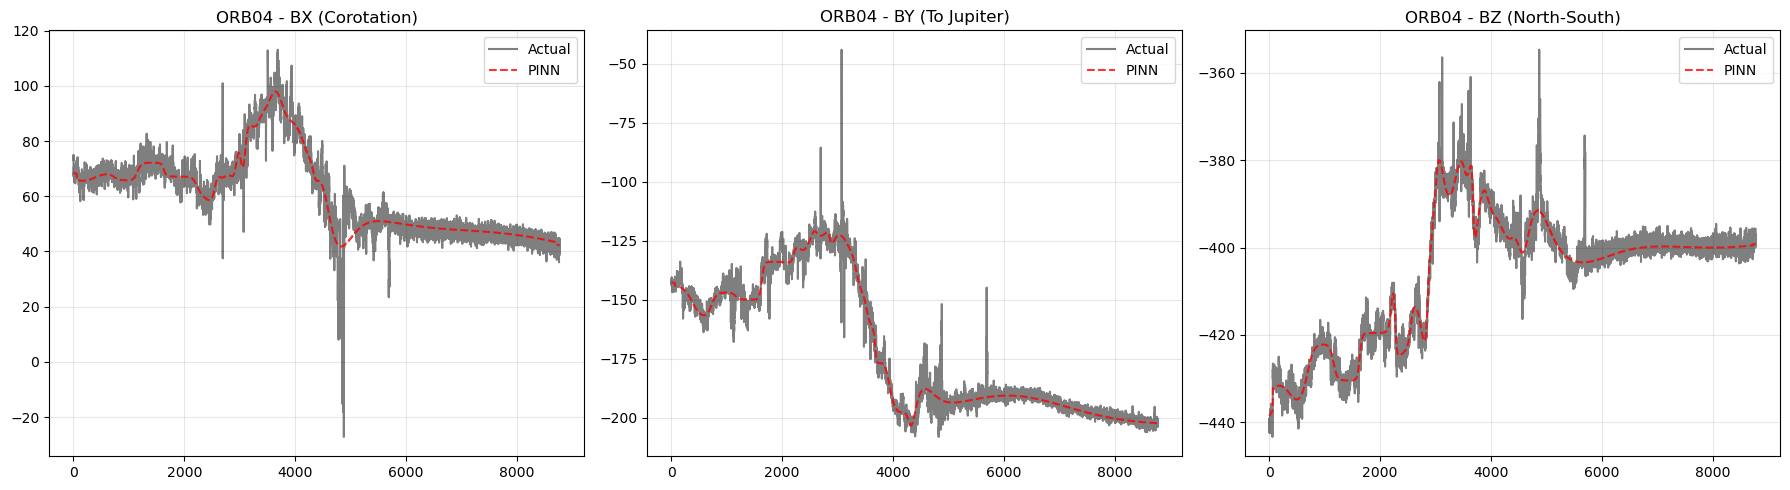

PINN Model for ORB04 saved.


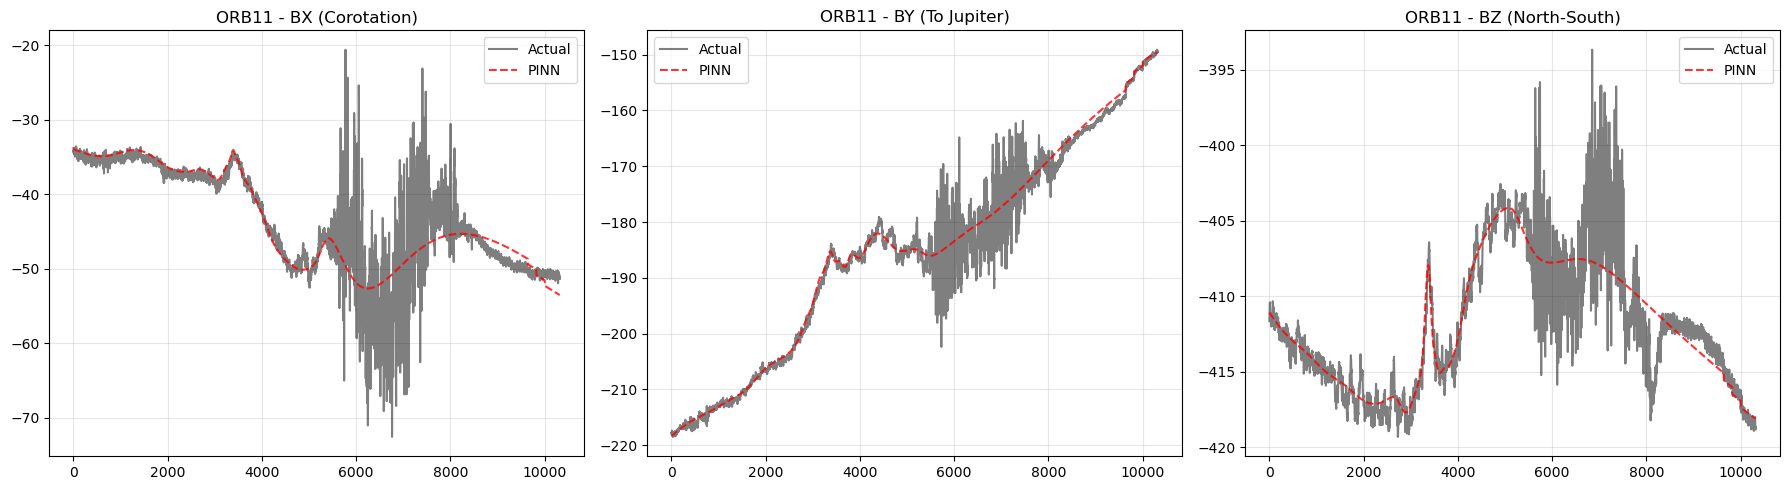

PINN Model for ORB11 saved.


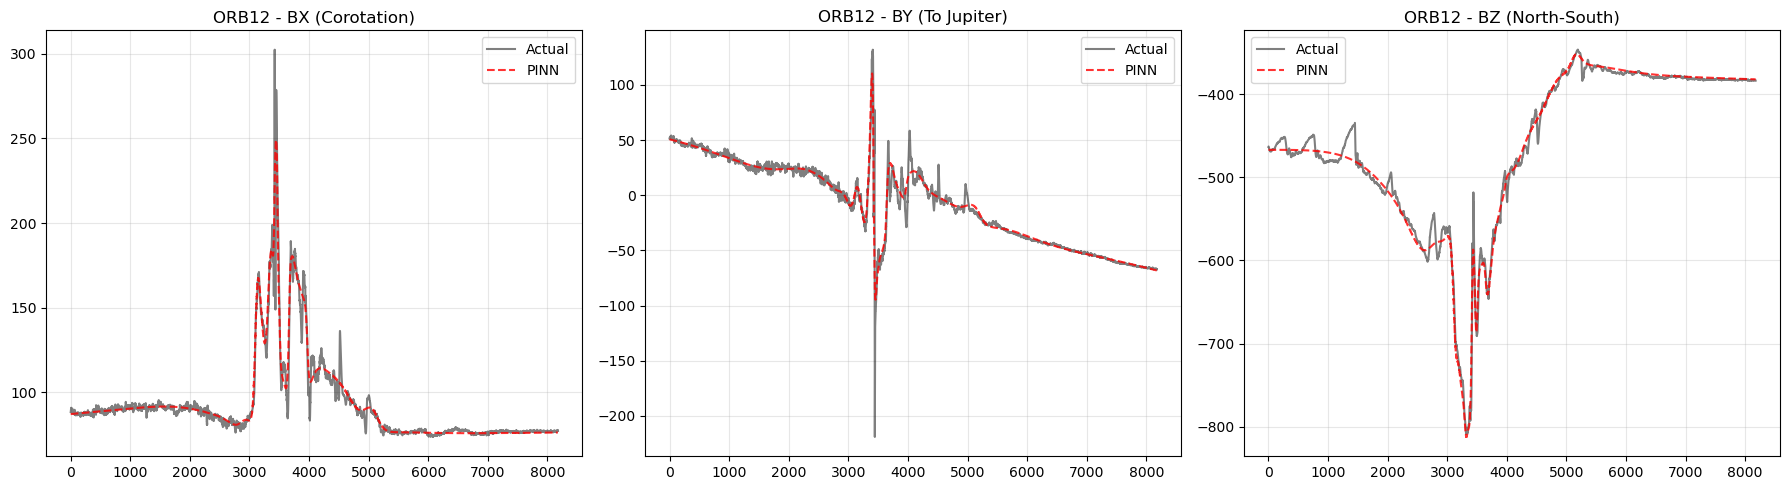

PINN Model for ORB12 saved.


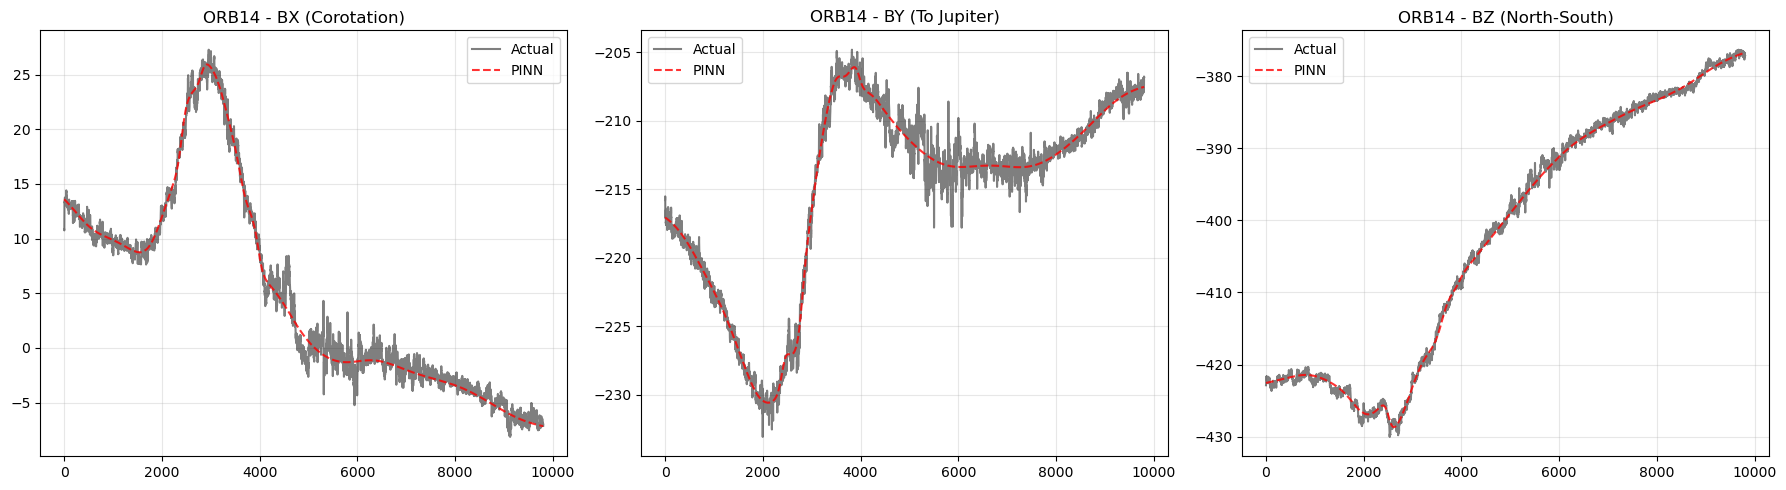

PINN Model for ORB14 saved.


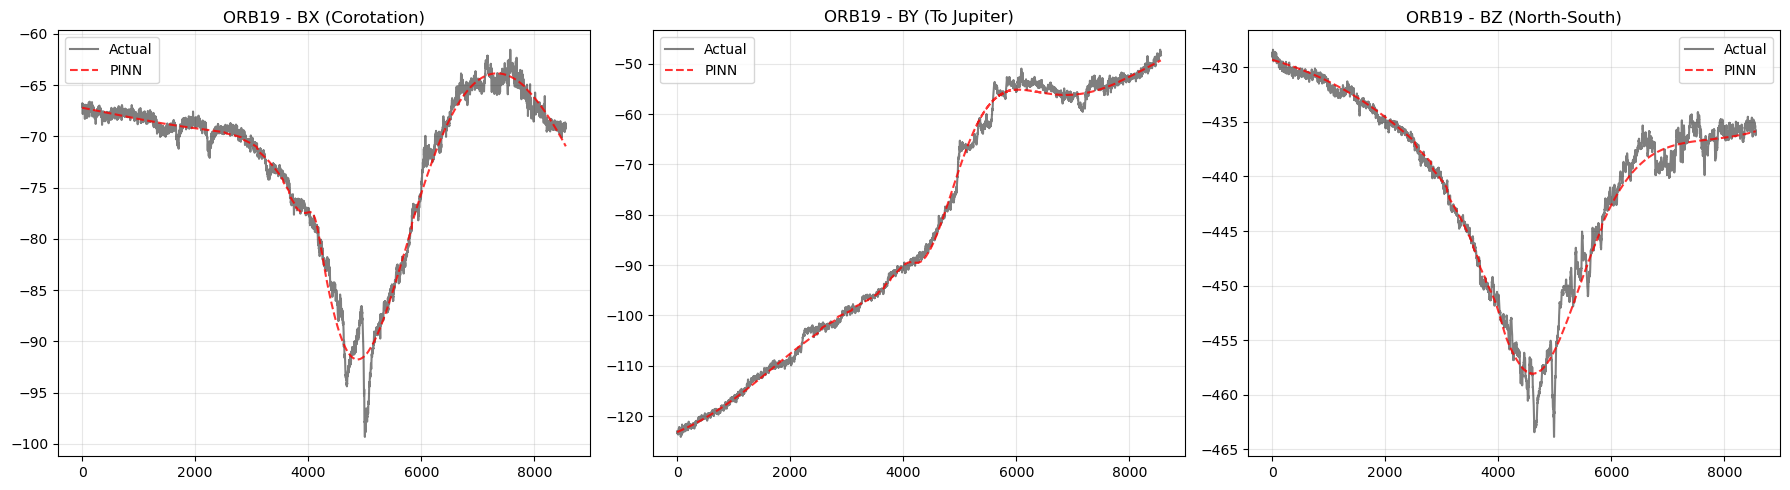

PINN Model for ORB19 saved.


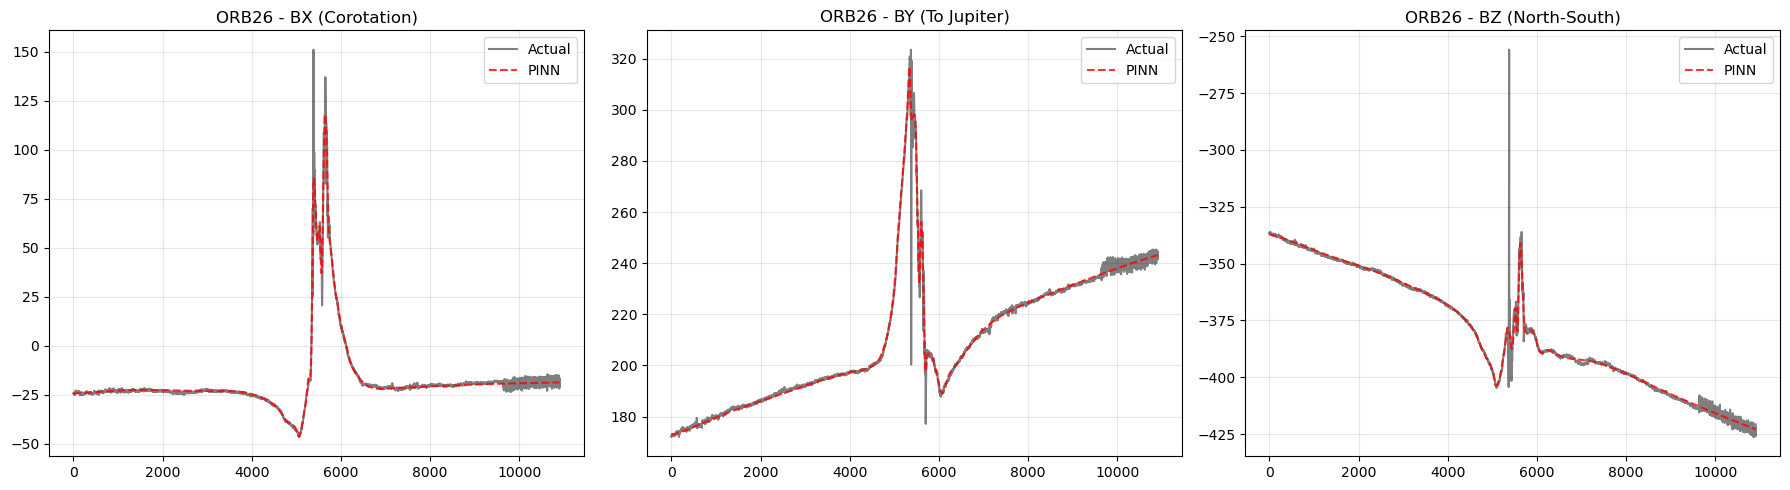

PINN Model for ORB26 saved.


In [19]:


for i, (orbit_packet, model_packet) in enumerate(zip(orbits_preproc_data, orbits_models_data)):

    model = PINN()

    data_tuple = orbit_packet[0]
    X_raw, y_raw, X_train, y_train, X_val, y_val, input_scaler, output_scaler = data_tuple

    model_state, loss_history = model_packet

    model.load_state_dict(model_state)

    model.eval()
    with torch.no_grad():
        X_scaled_current = input_scaler.transform(X_raw)
        X_tensor_current = torch.tensor(X_scaled_current, dtype=torch.float32)

        full_pred_scaled = model(X_tensor_current)
        full_pred = output_scaler.inverse_transform(full_pred_scaled.numpy())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    components = ['BX (Corotation)', 'BY (To Jupiter)', 'BZ (North-South)']

    for k in range(3):
        axes[k].plot(y_raw[:, k], 'k-', alpha=0.5, label='Actual')      # Black = Data
        axes[k].plot(full_pred[:, k], 'r--', alpha=0.8, label='PINN')   # Red = Model
        axes[k].set_title(f'{orbits[i]} - {components[k]}')
        axes[k].legend()
        axes[k].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'pinn_results_{orbits[i]}_3components.png')
    plt.show()

    # Save model
    torch.save(model.state_dict(), f'europa_pinn_model_{orbits[i]}.pth')
    print(f"PINN Model for {orbits[i]} saved.")



### Results for Bz for each fly-by
![ORB04](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB04_phys_lambda005.png)
![ORB11](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB11_phys_lambda005.png)
![ORB12](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB12_phys_lambda005.png)
![ORB14](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB14_phys_lambda005.png)
![ORB19](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB19_phys_lambda005.png)
![ORB26](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB26_phys_lambda005.png)

### Results for each axis for each fly-by
![ORB04](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB04_3components.png)
![ORB11](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB11_3components.png)
![ORB12](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB12_3components.png)
![ORB14](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB14_3components.png)
![ORB19](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB19_3components.png)
![ORB26](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB26_3components.png)

1. Conversion of results into data about salinity and ocean depth
2. Separate model for plasma
3. JUICE Callisto and Ganymede data in 2031
4. Better Europa data in 2030
5. Comparison of Numerical and PINN approach

### Additional - how the results would look like just for the NN?
![ORB04](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB04_3components_onlyNN.png)
![ORB11](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB11_3components_onlyNN.png)
![ORB12](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB12_3components_onlyNN.png)
![ORB14](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB14_3components_onlyNN.png)
![ORB19](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB19_3components_onlyNN.png)
![ORB26](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB26_3components_onlyNN.png)

### Additional 2 - Hyperbolic Tangent vs Sigmoid
![ORB04-Tanh](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB04_3components.png)
![ORB04-Sigmoid](/home/damian/Documents/Programming/Git/Physics_Informed_Neural_Networks/PINN_Application_for_Galileo_Europa_Data/PINN_app_to_Europa/pinn_results_ORB04_3components_sigmoid.png)